In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
!nvidia-smi

Mon May 25 09:27:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [16]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torchvision.models import ResNet18_Weights


In [17]:
TRAIN_PATH = "/content/drive/MyDrive/final project/data/fashion-mnist_train.csv"
TEST_PATH  = "/content/drive/MyDrive/final project/data/fashion-mnist_test.csv"

FEATURE_DIR = "/content/drive/MyDrive/final project/saved_features"
MODEL_DIR   = "/content/drive/MyDrive/final project/saved_models"

os.makedirs(FEATURE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

In [18]:
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

NUM_CLASSES = len(CLASS_NAMES)

In [19]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using Device: {DEVICE}")


Using Device: cuda


In [20]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),

    # NORMALIZATION
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),

    # NORMALIZATION
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

In [21]:
class FashionMNISTDataset(Dataset):

    def __init__(self, csv_file, transform=None):

        self.data = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        # LABEL
        label = int(self.data.iloc[idx, 0])

        # IMAGE PIXELS
        pixels = self.data.iloc[idx, 1:].values.astype(np.uint8)

        # CONVERT TO IMAGE
        image = Image.fromarray(
            pixels.reshape(28, 28),
            mode="L"
        ).convert("RGB")

        # APPLY TRANSFORM
        if self.transform:
            image = self.transform(image)

        return image, label

In [22]:
train_dataset = FashionMNISTDataset(
    TRAIN_PATH,
    transform=train_transform
)

test_dataset = FashionMNISTDataset(
    TEST_PATH,
    transform=test_transform
)


In [23]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

In [24]:
# LOAD PRETRAINED RESNET18
resnet_model = models.resnet18(
    weights=ResNet18_Weights.IMAGENET1K_V1
)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 204MB/s]


In [25]:
for param in resnet_model.parameters():
    param.requires_grad = False

# ============================================
# MODIFY FINAL LAYER
# ============================================
resnet_model.fc = nn.Linear(
    resnet_model.fc.in_features,
    NUM_CLASSES
)

resnet_model = resnet_model.to(DEVICE)

print("\nResNet18 Model Loaded Successfully")



ResNet18 Model Loaded Successfully


In [26]:
# ============================================
# LOSS FUNCTION
# ============================================
criterion = nn.CrossEntropyLoss()

# ============================================
# OPTIMIZER
# ============================================
optimizer = optim.Adam(
    resnet_model.fc.parameters(),
    lr=0.001
)


In [27]:
# FEATURE EXTRACTION FUNCTION
# SAVE FEATURES TO DISK
# ============================================
def extract_and_save_features(model, loader, save_path):

    print(f"\nExtracting features -> {save_path}")

    model.eval()

    features_list = []
    labels_list = []

    # REMOVE FINAL FC LAYER
    feature_extractor = nn.Sequential(
        *list(model.children())[:-1]
    )

    feature_extractor = feature_extractor.to(DEVICE)

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(DEVICE)

            # EXTRACT FEATURES
            features = feature_extractor(images)

            # FLATTEN FEATURES
            features = features.view(features.size(0), -1)

            features_list.append(
                features.cpu().numpy()
            )

            labels_list.append(
                labels.numpy()
            )

    # CONCATENATE
    features_array = np.concatenate(features_list, axis=0)
    labels_array   = np.concatenate(labels_list, axis=0)

    # SAVE TO DISK
    np.savez(
        save_path,
        features=features_array,
        labels=labels_array
    )

    print("Features Saved Successfully")
    print("Feature Shape:", features_array.shape)

In [28]:
# EXTRACT + SAVE FEATURES
# ============================================
extract_and_save_features(
    resnet_model,
    train_loader,
    os.path.join(FEATURE_DIR, "train_features.npz")
)

extract_and_save_features(
    resnet_model,
    test_loader,
    os.path.join(FEATURE_DIR, "test_features.npz")
)


Extracting features -> /content/drive/MyDrive/final project/saved_features/train_features.npz


/tmp/ipykernel_1599/3500142842.py:20: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(


Features Saved Successfully
Feature Shape: (60000, 512)

Extracting features -> /content/drive/MyDrive/final project/saved_features/test_features.npz
Features Saved Successfully
Feature Shape: (10000, 512)


In [29]:
# TRAINING
# ============================================
train_losses = []
train_accuracies = []

print("\nTraining ResNet18 Model...\n")

EPOCHS = 10

for epoch in range(EPOCHS):

    resnet_model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # ZERO GRADIENTS
        optimizer.zero_grad()

        # FORWARD PASS
        outputs = resnet_model(images)

        # LOSS
        loss = criterion(outputs, labels)

        # BACKPROPAGATION
        loss.backward()

        # UPDATE WEIGHTS
        optimizer.step()

        # CALCULATE LOSS
        total_loss += loss.item() * images.size(0)

        # PREDICTIONS
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()

        total += labels.size(0)

    # EPOCH METRICS
    epoch_loss = total_loss / total
    epoch_acc  = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_acc:.4f}"
    )



Training ResNet18 Model...



/tmp/ipykernel_1599/3500142842.py:20: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(


Epoch [1/10] Loss: 0.5993 Accuracy: 0.7944
Epoch [2/10] Loss: 0.4829 Accuracy: 0.8290
Epoch [3/10] Loss: 0.4667 Accuracy: 0.8346
Epoch [4/10] Loss: 0.4598 Accuracy: 0.8384
Epoch [5/10] Loss: 0.4487 Accuracy: 0.8403
Epoch [6/10] Loss: 0.4467 Accuracy: 0.8408
Epoch [7/10] Loss: 0.4470 Accuracy: 0.8423
Epoch [8/10] Loss: 0.4422 Accuracy: 0.8428
Epoch [9/10] Loss: 0.4399 Accuracy: 0.8435
Epoch [10/10] Loss: 0.4381 Accuracy: 0.8463


In [30]:
# SAVE TRAINED MODEL
# ============================================
MODEL_SAVE_PATH = os.path.join(
    MODEL_DIR,
    "resnet18_fashionmnist.pth"
)

torch.save(
    resnet_model.state_dict(),
    MODEL_SAVE_PATH
)

print(f"\nModel Saved Successfully")
print(f"Saved Path: {MODEL_SAVE_PATH}")


Model Saved Successfully
Saved Path: /content/drive/MyDrive/final project/saved_models/resnet18_fashionmnist.pth


In [31]:
# EVALUATION
# ============================================
resnet_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = resnet_model(images)

        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total

print(f"\nTest Accuracy: {test_accuracy:.4f}")


/tmp/ipykernel_1599/3500142842.py:20: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(



Test Accuracy: 0.8680


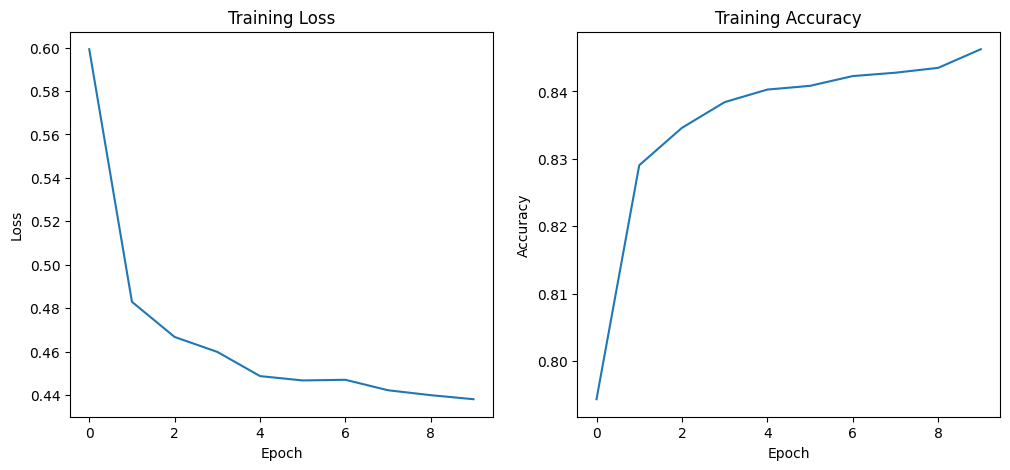

In [32]:
# PLOT TRAINING RESULTS
# ============================================
plt.figure(figsize=(12, 5))

# LOSS GRAPH
plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# ACCURACY GRAPH
plt.subplot(1, 2, 2)
plt.plot(train_accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()